# Car Price Prediction
This project predicts the resale price of used cars based on features like present price, 
kilometers driven, fuel type, and ownership history, using a Linear Regression model.

## Load and Explore the Dataset

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('car data.csv')

# Look at the first 5 rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Check the Car_Name Column

In [2]:
print(df['Car_Name'].nunique())
print(df['Car_Name'].unique())

98
<StringArray>
[                     'ritz',                       'sx4',
                      'ciaz',                   'wagon r',
                     'swift',             'vitara brezza',
                   's cross',                  'alto 800',
                    'ertiga',                     'dzire',
                  'alto k10',                     'ignis',
                       '800',                    'baleno',
                      'omni',                  'fortuner',
                    'innova',             'corolla altis',
               'etios cross',                   'etios g',
                'etios liva',                   'corolla',
                  'etios gd',                     'camry',
              'land cruiser', 'Royal Enfield Thunder 500',
        'UM Renegade Mojave',                 'KTM RC200',
         'Bajaj Dominar 400', 'Royal Enfield Classic 350',
                 'KTM RC390',            'Hyosung GT250R',
 'Royal Enfield Thunder 350',          

## Drop Car_Name (Too Many Unique Values)

In [3]:
# Drop Car_Name - too many unique values (98) to be useful for a small dataset
df = df.drop('Car_Name', axis=1)
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Check Categorical Columns

In [4]:
print(df['Fuel_Type'].unique())
print(df['Selling_type'].unique())
print(df['Transmission'].unique())

<StringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


## Encode Categorical Columns into Numbers

In [5]:
# Convert categorical columns into numeric columns
df = pd.get_dummies(df, columns=['Fuel_Type', 'Selling_type', 'Transmission'], drop_first=True)

df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


## Check Dataset Shape, Data Types, and Missing Values

In [17]:
# How many rows and columns?
print(df.shape)

# Data types and missing value overview
print(df.info())

# Confirm no missing values
print(df.isnull().sum())

# Quick statistics summary
print(df.describe())

(301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     301 non-null    int64  
 1   Selling_Price            301 non-null    float64
 2   Present_Price            301 non-null    float64
 3   Driven_kms               301 non-null    int64  
 4   Owner                    301 non-null    int64  
 5   Fuel_Type_Diesel         301 non-null    bool   
 6   Fuel_Type_Petrol         301 non-null    bool   
 7   Selling_type_Individual  301 non-null    bool   
 8   Transmission_Manual      301 non-null    bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 13.1 KB
None
Year                       0
Selling_Price              0
Present_Price              0
Driven_kms                 0
Owner                      0
Fuel_Type_Diesel           0
Fuel_Type_Petrol           0
Selling_type_Individual    0
Transmi

## Visualize Relationships with Selling Price

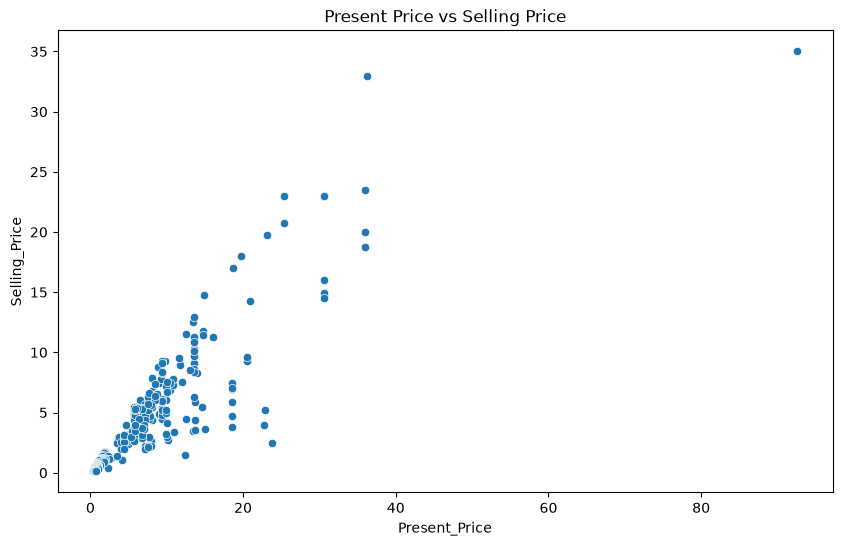

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualize relationships between key numeric features and Selling_Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Present_Price', y='Selling_Price')
plt.title('Present Price vs Selling Price')
plt.show()

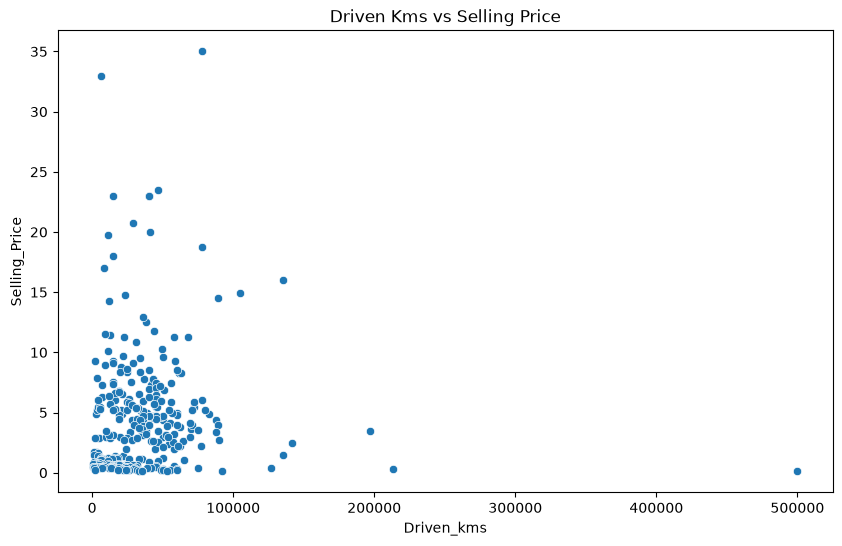

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Driven_kms', y='Selling_Price')
plt.title('Driven Kms vs Selling Price')
plt.show()

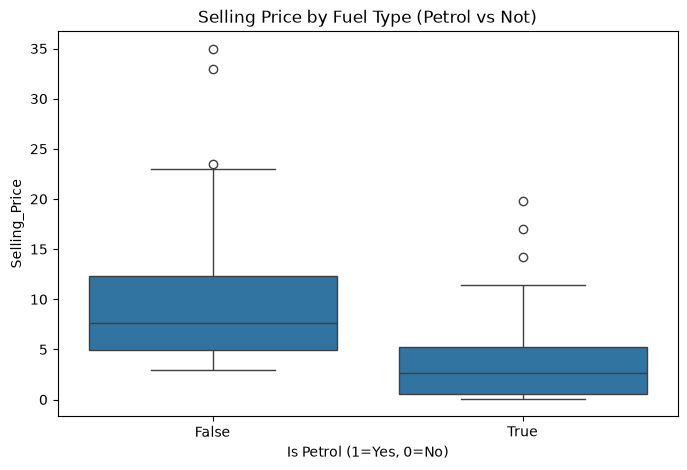

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Fuel_Type_Petrol', y='Selling_Price')
plt.title('Selling Price by Fuel Type (Petrol vs Not)')
plt.xlabel('Is Petrol (1=Yes, 0=No)')
plt.show()

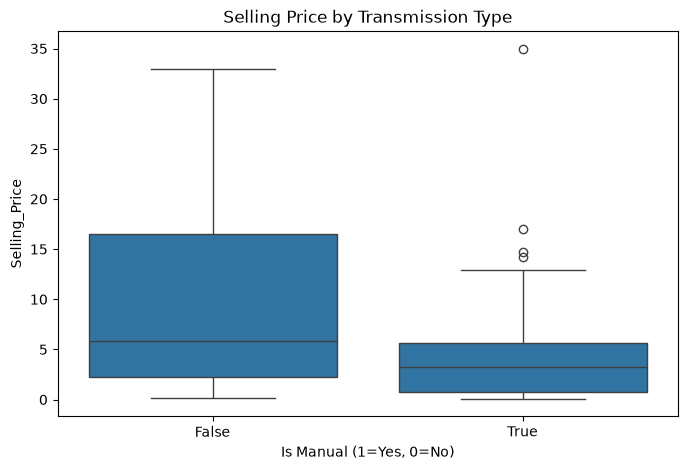

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Transmission_Manual', y='Selling_Price')
plt.title('Selling Price by Transmission Type')
plt.xlabel('Is Manual (1=Yes, 0=No)')
plt.show()

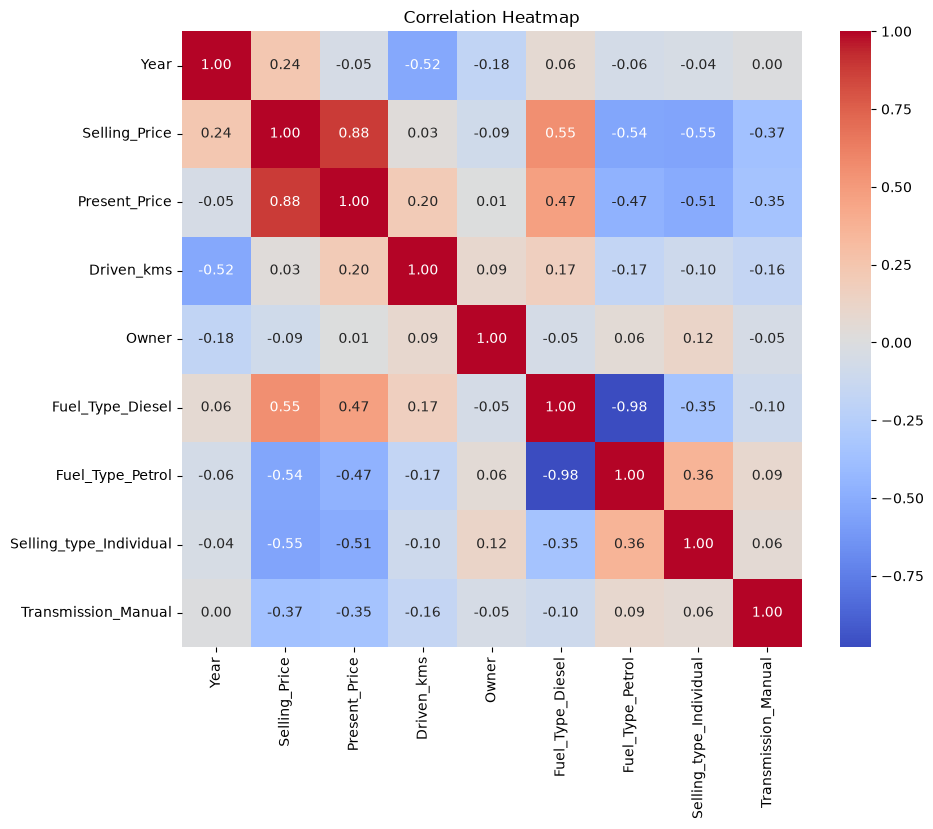

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Split Data into Training and Testing Sets

In [6]:
from sklearn.model_selection import train_test_split

# X = all input features (everything except Selling_Price)
X = df.drop('Selling_Price', axis=1)

# y = target (what we want to predict - Selling_Price)
y = df['Selling_Price']

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (240, 8)
Testing data size: (61, 8)


## Train the Model Using Linear Regression 


In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


## Evaluate Model Performance

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test data
y_pred = model.predict(X_test)

# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.393505747614133
Mean Squared Error (MSE): 5.685726747888061
Root Mean Squared Error (RMSE): 2.3844761998996886
R² Score: 0.8217506865344353


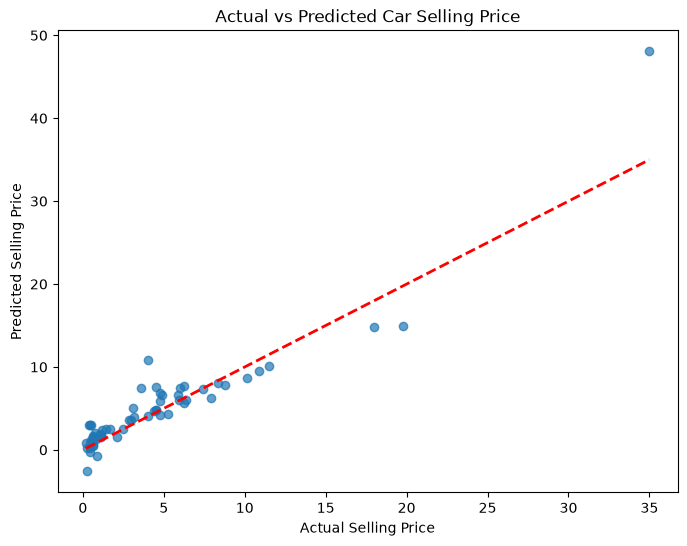

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Car Selling Price')
plt.show()

## Check Feature Importance

In [14]:
# See how much weight the model gave to each feature
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("\nIntercept (baseline price):", model.intercept_)

                   Feature  Coefficient
0                     Year     0.374840
1            Present_Price     0.512116
2               Driven_kms    -0.000007
3                    Owner    -1.129691
4         Fuel_Type_Diesel     2.174294
5         Fuel_Type_Petrol     0.544911
6  Selling_type_Individual    -0.463278
7      Transmission_Manual    -1.024018

Intercept (baseline price): -753.4284664457933
